# Embedding Words in LLMs

In this notebook, we will start to discuss Large Language Models (LLMs) and the machinery that makes them work.

**Learning Objectives**

1. Outline the structure of a LLM neural network
2. Explain how text is converted to tokens
3. Describe how tokens are embeddeded in a continuous vector for use in a neural network

**Import modules**

Begin by importing the modules to be used in this notebook

In [4]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from torch import nn
from IPython.display import Image as IPI

In [2]:
from transformers import GPT2Tokenizer, GPT2Model, GPT2LMHeadModel
import torch

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


### Large Language Models

Large language models have exploded in popularity in recent years. While there are various flavors of LLMs, many share very similar structures. Here we will examine the architecture of the GPT-2 (small) model since 1) it is compact enough to run on a laptop; 2) the pre-trained weights for the model are freely available online; and 3) the architecture of GPT-2 forms a basis to understand other more recent variants such as GPT-5 or DeepSeek-V3. This notebook is derived from the example in [Build a Large Language Model (from Scratch)](https://github.com/rasbt/LLMs-from-scratch) by Sebastian Raschka.

In this notebook, we'll examine a major component of GPT-2: the tokenization and embedding of text into vectors. 

In the subsequent notebook, we'll take a look at the attention mechanism at the heart of the transformer architecture, and will put these pieces together to construct (and run) the entire GPT-2 model by loading in pre-trained weights to our machine.

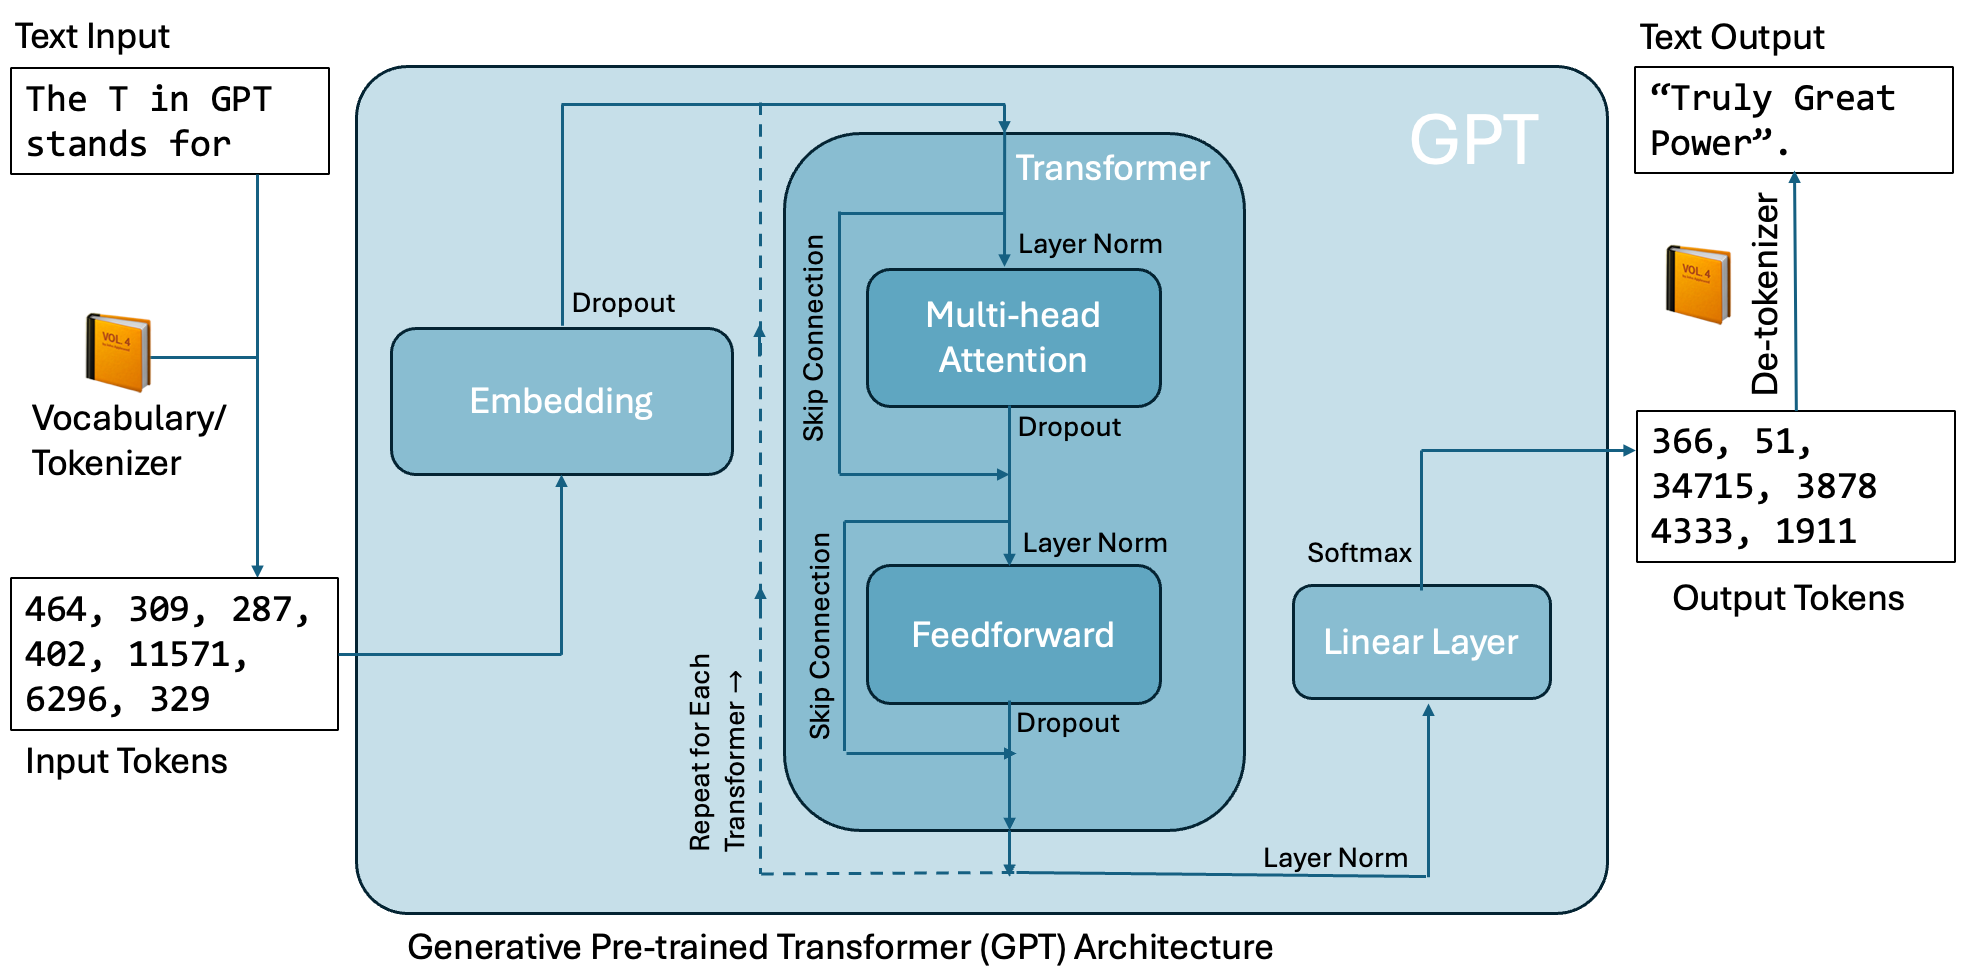

In [5]:
display(IPI(filename=os.path.join('..','images', 'GPT_Schematic.png'), width=500))

## Tokenizing and Embedding Text

One of the first steps in creating an LLM is to create a procedure by which words can be converted to continuous vectors. This process is done in two steps: the conversion of words to *tokens* (integers) and then the embedding of tokens into continuous vectors. The tokenization and embedding component can be seen on the left side of the diagram above, converting the input text *The T in GPT stands for* to "tokens" i.e. integers that are subsequently "embedded" into vectors. These vectors are passed through the GPT architecture yielding additional tokens, that are then converted back to words. We'll explore these two components below.

### Tokenizing Text

To convert from text to tokens, we need to generate a *vocabulary* that maps words to integers. One easy way we could do this is to generate a dictionary that maps all known words to integers. For example, pretend all known words are in the sentence "The T in GPT stands for". Then, we could make a vocabulary as follows:

In [6]:
vocab = {'for':0, 'in':1, 'stands':2,
         'GPT':3, 'T': 4, 'The':5}

Using this vocabulary, we can tokenize our phrase as:

In [7]:
tokens = []
for word in 'The T in GPT stands for'.split():
    tokens.append(vocab[word])
print(tokens)

[5, 4, 1, 3, 2, 0]


Similarly, we could decode these tokens back to words with a reversed dictionary

In [8]:
reversed_vocab = {0: 'for', 1: 'in', 2: 'stands', 3: 'GPT', 4: 'T', 5: 'The'}

In [9]:
phrase = ''
for token in tokens:
    phrase += reversed_vocab[token]+' '
print(phrase)

The T in GPT stands for 


#### Tokenization in GPT-2

This is a simple approach, but it runs into a few issues - one of the largest is that it is unable to handle new words that were not encountered before. For this reason, most LLMs use a **byte pair encoding**, which generates tokens which are parts of words that can be used to construct larger words. Let's have a look at the tokenizer used in GPT-2. We can load that in as follows:

In [11]:
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

Using this tokenizer, let's pass in our phrase:

In [12]:
gpt2_inputs = gpt2_tokenizer('The T in GPT stands for', return_tensors="pt")['input_ids'][0].numpy()

In [13]:
print(gpt2_inputs)

[  464   309   287   402 11571  6296   329]


As we can see, we have more tokens here than words. Let's see what each token corresponded to:

In [14]:
for token in gpt2_inputs:
    decoded_text = gpt2_tokenizer.decode(token)
    print(token, decoded_text)

464 The
309  T
287  in
402  G
11571 PT
6296  stands
329  for


Here, we see that some of the words get their own tokens - but the G and PT in GPT are broken up into two separate tokens, and there is a separate token for T. 

### Embedding Vectors

The tokenization of text is one step in preparing words for neural networks, but we're not quite ready to run this through a network itself. One option we *could* consider is a one-hot encoding, similar to what we did for the MNIST images. However, this would result in some pretty big matrices.

One alternative is to consider an embedding - a transformation from integers to a continuous vector. For example, consider our small dictionary with 6 entries above. We could convert each of these to a 3-dimensional embedding using the following embedding matrix:

In [15]:
torch.manual_seed(17)
vocab_length = 6
embedding_dim = 3
embedding_matrix = nn.Embedding(vocab_length, embedding_dim)
print(embedding_matrix.weight)

Parameter containing:
tensor([[-1.0462,  1.2305, -1.1597],
        [ 0.6124,  0.3518,  0.1863],
        [ 0.9567,  0.0895,  0.0068],
        [-1.7377, -0.6994,  1.1373],
        [ 0.2750, -0.4114,  0.1158],
        [-0.2154,  0.6582,  0.2169]], requires_grad=True)


This matrix is initialized with small random values but the parameters of this matrix will be learned as part of the training process. To use this embedding, we simply access the rows in this matrix for each token:

In [16]:
# generate a substring
substring = 'The T in GPT'

# tokenize
tokens = []
for word in substring.split():
    tokens.append(vocab[word])
print('Tokens:\n',tokens)

# embed
embedded_inputs = embedding_matrix.weight[torch.tensor(tokens)]
print('Embedded Inputs:\n',embedded_inputs)

Tokens:
 [5, 4, 1, 3]
Embedded Inputs:
 tensor([[-0.2154,  0.6582,  0.2169],
        [ 0.2750, -0.4114,  0.1158],
        [ 0.6124,  0.3518,  0.1863],
        [-1.7377, -0.6994,  1.1373]], grad_fn=<IndexBackward0>)


As we can see, there are 4 rows in the embedded input - one for each of the tokens. Further, each row has length 3, equal to our embedding dimension. 

### Embedding in GPT-2
For GPT-2, the embedded vectors have dimension 768. Let's check out what these vectors look like using the embedding from that model. Here, we'll load that in and write a quick function for the embedding:

In [19]:
# load tokenizer and model
model = GPT2Model.from_pretrained("gpt2")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [20]:
# define a function to return the GPT-2 embedding
def return_gpt2_embedding(text):
    # tokenize text
    inputs = gpt2_tokenizer(text, return_tensors="pt")
    
    # get token embeddings from GPT-2
    with torch.no_grad():
        outputs = model(**inputs)
        last_hidden_states = outputs.last_hidden_state

    # acquire the embedding
    embedding = last_hidden_states.mean(dim=1).squeeze(0)
    embedding = embedding.cpu().numpy()
    
    return(embedding)

Using this embedding function, we can compute the embedding for any word. Let's put in some common words and compute their embedding:

In [21]:
embeddings = []
words = ['seal','California','whale','Oregon','manatee','Washington']
for text in words:
    embedding = return_gpt2_embedding(text)
    embeddings.append(embedding)

Each of these embeddings is an array with length 768. We can check that here:

In [22]:
print(np.shape(embeddings[0]))

(768,)


Clearly, we can't visually compare the embeddings with this dimension size directly - but we can use PCA for this task. Let's write some quick code for PCA: 

In [23]:
# make a design matrix
X = np.column_stack(embeddings)

# normalize the columns
for s in range(np.shape(X)[1]):
    vals = X[:,s]
    vals = (vals - np.mean(vals))/np.std(vals)
    X[:,s] = vals

# the compute the eigenvalues and eigenvectors
R = np.cov(X, rowvar=False)
values, vectors = linalg.eig(R)
values = np.real(values)

# compute the factor loading matrix
A = vectors@np.sqrt(np.diag(values))

As in our previous exploration, let's check out which embeddings vary together:

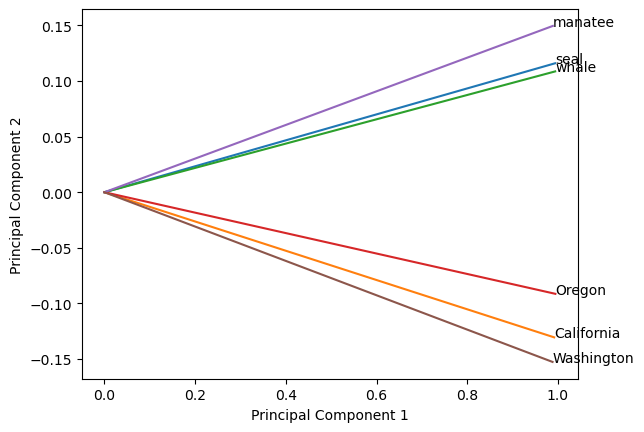

In [24]:
for i, txt in enumerate(words):
    plt.plot([0,A[i,0]], [0,A[i,1]],'-', markersize=8)
    plt.text(A[i,0],A[i,1],txt)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2');

From the results of our PCA, we can see that similar words are clustered together - this is the goal of the embedding! The larger the embedding vector, the more context can be included. As a result, each new iteration of LLMs have included larger and larger embedding vectors, as shown in the following table:

|Model Variant | Embedding Dim |
|--------------|---------------|
|GPT-2 Small | 768 |
|GPT-2 Medium | 1024 |
|GPT-2 Large | 1280 |
|GPT-2 XL | 1600 |
|GPT-3 Ada | 1024 |
|GPT-3 Babbage | 2048 |
|GPT-3 Curie | 4096 |
|GPT-3 Davinci | 12288 |
|GPT-3.5 | 12288  |
|GPT-4	| ~15000 (estimated) |
|GPT-4 Turbo | 11000–15000 (estimated)  |
|GPT-5	| ~20k+ (estimated) |

### Passing Tokens to a GPT Model

Before we move on to the next topic, it's helpful to see a full example of how an LLM is used to make predictions. Here, we'll use the pretrained GPT-2 model:

In [25]:
model = GPT2LMHeadModel.from_pretrained("gpt2")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

To begin, let's tokenize some text:

In [26]:
# introduce some text as a prompt
text = 'The T in GPT stands for'
print('Input text:',text)

# encode the text as tokens
encoded_tensor = gpt2_tokenizer(text, return_tensors="pt")['input_ids']
print('Tokens:',encoded_tensor[0].numpy())

Input text: The T in GPT stands for
Tokens: [  464   309   287   402 11571  6296   329]


Next, we pass these tokens into the model to generate new ones. When tokens are passed into the model, the model produces a set of *logits* which we convert to probabilities using the softmax function. This is the same procedure we have seen in previous notebooks (e.g. the [Logistic Regression](https://profmikewood.github.io/machine_learning_book/logistic-regression/) notebook). Let's see how this works:

In [27]:
# choose a number of tokens to produce
max_new_tokens = 6

# iterate to produce new tokens
for i in range(max_new_tokens):

    # compute logits from the model
    with torch.no_grad():
        logits = model(encoded_tensor).logits

    # get the logit for the final token and convert to probabilities
    logits = logits[:, -1, :]
    probabilities = torch.softmax(logits, dim=-1)

    # get the token ID corresponding to the highest probability
    idx_next = torch.argmax(probabilities, dim=-1, keepdim=True)

    # add the next token to the encoded tensor
    encoded_tensor = torch.cat((encoded_tensor, idx_next), dim=1)

Let's see what our new tokens are:

In [28]:
print('New Tokens:', encoded_tensor[0].numpy())

New Tokens: [  464   309   287   402 11571  6296   329   366    51 34715  3878  4333
  1911]


Once we've obtained our new tokens, we need to convert them back to text.

In [29]:
decoded_text = gpt2_tokenizer.decode(encoded_tensor[0])
print('Output text:', decoded_text)

Output text: The T in GPT stands for "Truly Great Power".


As you can see, the model is designed to compute the embeddings (this matrix has learnable parameters after all) but the tokenization is a pre- and post-processing step to make sense of encoded text.

**Key Takeaways**

1. A GPT-like architecture has an embedding, multiple transformer layers, and an output layer returning the probabilities that a given token in the vocabulary is the next token.
2. The embedding layer converts input tokens into continuous vectors.